In [14]:
import torch
from dinosaw.utils import do_2D_pca
from dinosaw.helpers import ModelTypes, model_names, get_models, get_features, add_custom_font

import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import minmax_scale, scale
from os import listdir

from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import font_manager


SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = 'cuda:0'

In [15]:
enabled_models: tuple[ModelTypes, ...] = ('dv2', 'alibi_dv2_coco')
models = get_models(enabled_models, '../../trained_models', DEVICE, False)

In [16]:
def hide_axes(ax: plt.Axes):
    ax.set_xticks([])
    ax.set_yticks([])
    if hasattr(ax, 'set_zticks'):
        ax.set_zticks([])

In [17]:
def get_shared_pca(features_: list[np.ndarray], fg_masks: list[np.ndarray]) -> PCA:
    all_features = []
    for feature, fg_mask in zip(features_, fg_masks):
        masked = feature[fg_mask]
        all_features.append(masked)
        print(feature.shape, fg_mask.shape, masked.shape)
    all_features_concat = np.concatenate(all_features, axis=0)
    all_features_scaled = scale(all_features_concat, axis=0)
    pca = PCA(n_components=3)
    pca.fit(all_features_scaled)
    return pca

def apply_shared_pca(features: np.ndarray, fg_mask: np.ndarray, pca: PCA) -> np.ndarray:
    h, w, c = features.shape
    valid_features = features[fg_mask]
    features_scaled = scale(valid_features, axis=0)
    emb_3d = pca.transform(features_scaled)
    emb_3d_minmax = minmax_scale(emb_3d, feature_range=(0, 1), axis=0)

    out = np.zeros((h, w, 3), dtype=np.float32)
    out[fg_mask] = emb_3d_minmax
    return out

def _get(red_li, img_idx, ch, thr) -> np.ndarray:
    return red_li[img_idx][: , :, ch] > thr

In [18]:
images: list[Image.Image] = []
path = '../paper_figures/data/shared_pca/'
folder_name = 'bison'

for file_name in listdir(f'{path}/{folder_name}'):
    img = Image.open(f'{path}/{folder_name}/{file_name}').convert('RGB')

    shortest = min(img.size)
    L = 384
    sf = L / shortest
    # new_size = (int(img.size[0] * sf), int(img.size[1] * sf))
    new_size = (574, 384)
    img = img.resize(new_size, resample=Image.BILINEAR)

    images.append(img)

In [19]:
features = {k: [] for k in enabled_models}
features_reduced = {k: [] for k in enabled_models}
for img in images:
    for name, model in models.items():
        print(img.size)
        feat = get_features(model, img)
        reduced = do_2D_pca(feat, 3, pre_norm='std', post_norm='minmax')
        features[name].append(feat)
        features_reduced[name].append(reduced)

(574, 384)
(574, 384)
(574, 384)
(574, 384)
(574, 384)
(574, 384)
(574, 384)
(574, 384)


In [20]:
# bison
red = features_reduced[enabled_models[-1]]
fg_masks =[_get(red, 0, 1, 0.6), ~_get(red, 1, 0, 0.3), ~_get(red, 2, 0, 0.3), ~_get(red, 3, 0, 0.4)]

selected_masks = fg_masks

In [21]:
%%capture
dv2_feats_tr = [f.transpose(1, 2, 0) for f in features[enabled_models[0]]]
dv2_shared_pca = get_shared_pca(dv2_feats_tr, fg_masks)

alibi_feats_tr = [f.transpose(1, 2, 0) for f in features[enabled_models[-1]]]
alibi_shared_pca = get_shared_pca(alibi_feats_tr, selected_masks)

dv2_fg_feats_reduced = [apply_shared_pca(feats, mask, dv2_shared_pca) for feats, mask in zip(dv2_feats_tr, selected_masks)]
alibi_fg_feats_reduced = [apply_shared_pca(feats, mask, alibi_shared_pca) for feats, mask in zip(alibi_feats_tr, selected_masks)]

In [22]:
images_: list[Image.Image] = []
path = '../paper_figures/data/shared_pca/'
folder_name = 'elephants'

for file_name in listdir(f'{path}/{folder_name}'):
    img = Image.open(f'{path}/{folder_name}/{file_name}').convert('RGB')

    shortest = min(img.size)
    L = 384
    sf = L / shortest
    # new_size = (int(img.size[0] * sf), int(img.size[1] * sf))
    new_size = (574, 384)
    img = img.resize(new_size, resample=Image.BILINEAR)

    images_.append(img)

In [23]:
features_ = {k: [] for k in enabled_models}
features_reduced_ = {k: [] for k in enabled_models}
for img in images_:
    for name, model in models.items():
        print(img.size)
        feat = get_features(model, img)
        reduced = do_2D_pca(feat, 3, pre_norm='std', post_norm='minmax')
        features_[name].append(feat)
        features_reduced_[name].append(reduced)

(574, 384)
(574, 384)
(574, 384)
(574, 384)
(574, 384)
(574, 384)
(574, 384)
(574, 384)


In [24]:
red = features_reduced_[enabled_models[0]]
fg_masks = [_get(red, 0, 0, 0.65), ~_get(red, 1, 0, 0.3), _get(red, 2, 0, 0.7), ~_get(red, 3, 0, 0.6)  ] 

selected_masks_ = fg_masks

In [25]:
%%capture
dv2_feats_tr = [f.transpose(1, 2, 0) for f in features_[enabled_models[0]]]
dv2_shared_pca = get_shared_pca(dv2_feats_tr, fg_masks)

alibi_feats_tr = [f.transpose(1, 2, 0) for f in features_[enabled_models[-1]]]
alibi_shared_pca = get_shared_pca(alibi_feats_tr, selected_masks_)

dv2_fg_feats_reduced_ = [apply_shared_pca(feats, mask, dv2_shared_pca) for feats, mask in zip(dv2_feats_tr, selected_masks_)]
alibi_fg_feats_reduced_ = [apply_shared_pca(feats, mask, alibi_shared_pca) for feats, mask in zip(alibi_feats_tr, selected_masks_)]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


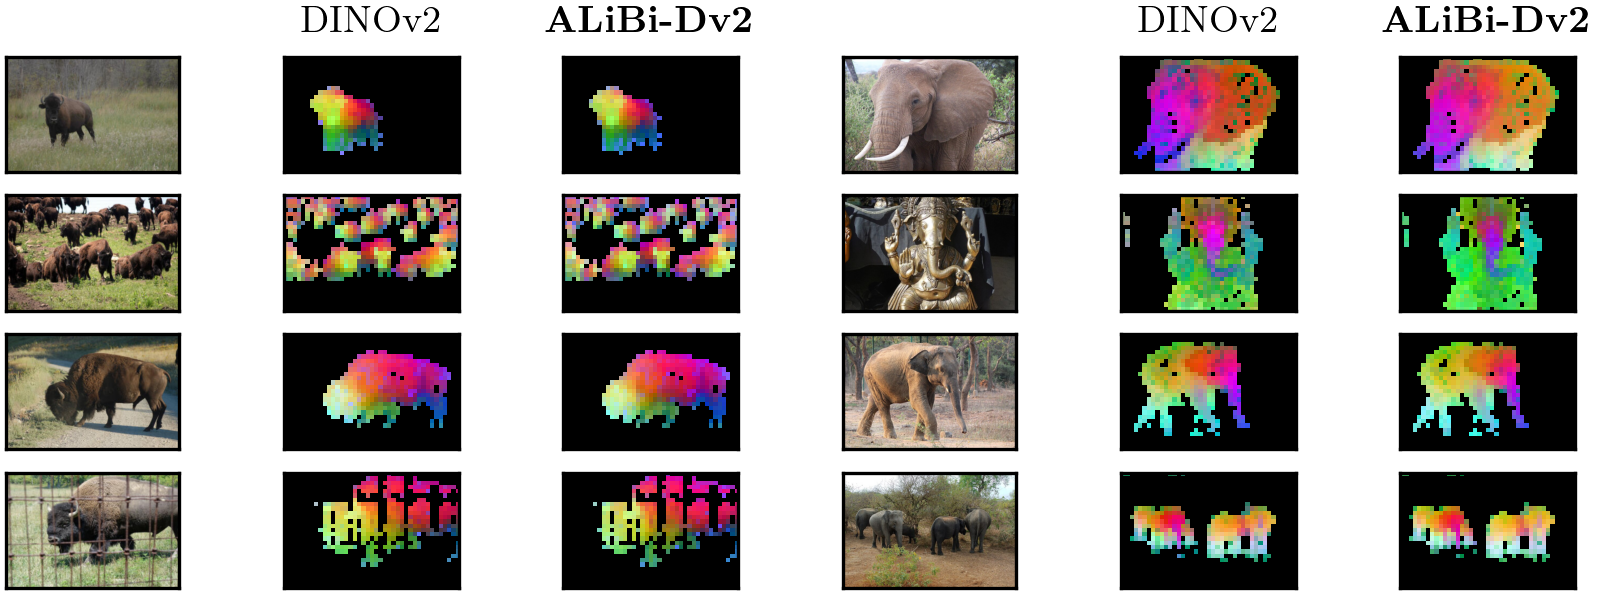

In [31]:
# %%capture
plt.style.use("thesis.mplstyle")
W, H = 7, 2.3

# add_custom_font('resources/fonts', 'Grotesk')
fig, axs = plt.subplots(len(images), 6, figsize=(W, H))

for i, (img, dv2_reduced, alibi_reduced, mask) in enumerate(zip(images, dv2_fg_feats_reduced, alibi_fg_feats_reduced, selected_masks)):
    axs[i, 0].imshow(img)
    hide_axes(axs[i, 0])

    axs[i, 1].imshow(dv2_reduced * mask[:, :, np.newaxis])
    hide_axes(axs[i, 1])
    

    axs[i, 2].imshow(alibi_reduced * mask[:, :, np.newaxis])
    hide_axes(axs[i, 2])

    if i == 0:
        axs[i, 1].set_title('DINOv2')
        axs[i, 2].set_title(r'\textbf{ALiBi-Dv2}', weight=700)


for i, (img, dv2_reduced, alibi_reduced, mask) in enumerate(zip(images_, dv2_fg_feats_reduced_, alibi_fg_feats_reduced_, selected_masks_)):
    axs[i, 3].imshow(img)
    hide_axes(axs[i, 3])

    axs[i, 4].imshow(dv2_reduced * mask[:, :, np.newaxis])
    hide_axes(axs[i, 4])
    

    axs[i, 5].imshow(alibi_reduced * mask[:, :, np.newaxis])
    hide_axes(axs[i, 5])

    if i == 0:
        axs[i, 4].set_title('DINOv2',)
        axs[i, 5].set_title(r'\textbf{ALiBi-Dv2}', )

# plt.tight_layout()
# plt.savefig('saved/03b.png', dpi=300)
plt.savefig("out/shared_pcas.pdf", bbox_inches='tight', )